# U-Net - Single Channel SAR Data Tree Species Classification


In [1]:
import math
import os
import sys
import json
import numpy as np
from glob import glob
import rasterio
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm
from collections import Counter
import multiprocessing as mp
from datadings.reader import ZipFileReader, MsgpackReader

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score
import random
import time
from datetime import datetime

# Set random seeds for reproducibility
def set_random_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_random_seeds(42)
print("Random seed set to 42")


Random seed set to 42


## Load Data

In [2]:
# Data configuration
BASE_PATH = 'treesat_ori'
LABELS_FILE = os.path.join(BASE_PATH, 'labels/TreeSatBA_v9_60m_multi_labels.json')
RES_SENTINEL = '60m'                                     
TRAIN_FILENAMES = open(os.path.join(BASE_PATH, 'train_filenames.lst')).read().split()
TEST_FILENAMES = open(os.path.join(BASE_PATH, 'test_filenames.lst')).read().split()

print(f"Training samples: {len(TRAIN_FILENAMES)}")
print(f"Testing samples: {len(TEST_FILENAMES)}")


Training samples: 45337
Testing samples: 5044


In [3]:
# Load label data
multilabels_dict = json.load(open(LABELS_FILE))

class_counts = Counter()
for mls in multilabels_dict.values():
    for ml, p in mls:
        class_counts[ml] += 1

classes = sorted(class_counts)
print(f"Number of classes: {len(classes)}")
print(f"Class list: {classes}")


Number of classes: 15
Class list: ['Abies', 'Acer', 'Alnus', 'Betula', 'Cleared', 'Fagus', 'Fraxinus', 'Larix', 'Picea', 'Pinus', 'Populus', 'Prunus', 'Pseudotsuga', 'Quercus', 'Tilia']


In [6]:
# Simplified data loading with outlier handling
print("=== Loading SAR data ===")

# Load original three-channel data
labels_train = np.load(os.path.join(BASE_PATH, 'labels_train.npy'))
labels_test = np.load(os.path.join(BASE_PATH, 'labels_test.npy'))
data_60m_train = np.load(os.path.join(BASE_PATH, 'data_60m_train.npy'))
data_60m_test = np.load(os.path.join(BASE_PATH, 'data_60m_test.npy'))

print(f"Original data shape: {data_60m_train.shape}")
print(f"Channel meaning: [VV, VH, VV/VH ratio]")

# Handle outliers: replace -9999 with channel-specific means
train_clean = data_60m_train.copy()
test_clean = data_60m_test.copy()

# Calculate means for each channel (excluding -9999 values)
channel_means = []
for i, channel_name in enumerate(['VV', 'VH', 'VV/VH ratio']):
    channel_data = train_clean[:, i, :, :]
    # Only use values that are not -9999 for mean calculation
    valid_mask = channel_data > -9990
    if valid_mask.sum() > 0:
        channel_mean = channel_data[valid_mask].mean()
    else:
        # If all values are -9999, use 0 as fallback
        channel_mean = 0.0
    channel_means.append(channel_mean)

# Replace outliers with channel-specific means
for i, mean_val in enumerate(channel_means):
    train_clean[:, i, :, :] = np.where(train_clean[:, i, :, :] < -9990, mean_val, train_clean[:, i, :, :])
    test_clean[:, i, :, :] = np.where(test_clean[:, i, :, :] < -9990, mean_val, test_clean[:, i, :, :])

print(f"Train: {train_clean.shape}")
print(f"Test: {test_clean.shape}")

# Analyze cleaned data
for i, channel_name in enumerate(['VV', 'VH', 'VV/VH ratio']):
    channel_data = train_clean[:, i, :, :]
    print(f"\n{channel_name} channel:")
    print(f"  Min value: {channel_data.min():.4f}")
    print(f"  Max value: {channel_data.max():.4f}")
    print(f"  Mean value: {channel_data.mean():.4f}")
    print(f"  Std deviation: {channel_data.std():.4f}")

# Prepare data for training
def prepare_image_level_data(images, labels):
    """Keep image-level labels for classification task"""
    return images, labels

# Prepare image-level data
print("\nImage-level data for classification:")
X_train_img, y_train_img = prepare_image_level_data(train_clean, labels_train)
X_test_img, y_test_img = prepare_image_level_data(test_clean, labels_test)

print(f"    Training data range: [{X_train_img.min():.3f}, {X_train_img.max():.3f}]")
print(f"    Testing data range: [{X_test_img.min():.3f}, {X_test_img.max():.3f}]")

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_img)
y_train_tensor = torch.LongTensor(y_train_img)
X_test_tensor = torch.FloatTensor(X_test_img)
y_test_tensor = torch.LongTensor(y_test_img)

print(f"\nPyTorch tensor shapes:")
print(f"  X_train: {X_train_tensor.shape}")
print(f"  y_train: {y_train_tensor.shape}")
print(f"  Task: Image-level classification with 3-channel input")


=== Loading SAR data ===
Original data shape: (45337, 3, 6, 6)
Channel meaning: [VV, VH, VV/VH ratio]
Train: (45337, 3, 6, 6)
Test: (5044, 3, 6, 6)

VV channel:
  Min value: -31.2206
  Max value: 22.7386
  Mean value: -6.1622
  Std deviation: 3.7076

VH channel:
  Min value: -49.7253
  Max value: 21.9384
  Mean value: -12.4083
  Std deviation: 3.4777

VV/VH ratio channel:
  Min value: -288.3494
  Max value: 987.3040
  Mean value: 0.4745
  Std deviation: 1.2973

Image-level data for classification:
    Training data range: [-288.349, 987.304]
    Testing data range: [-108.609, 1259.181]

PyTorch tensor shapes:
  X_train: torch.Size([45337, 3, 6, 6])
  y_train: torch.Size([45337])
  Task: Image-level classification with 3-channel input


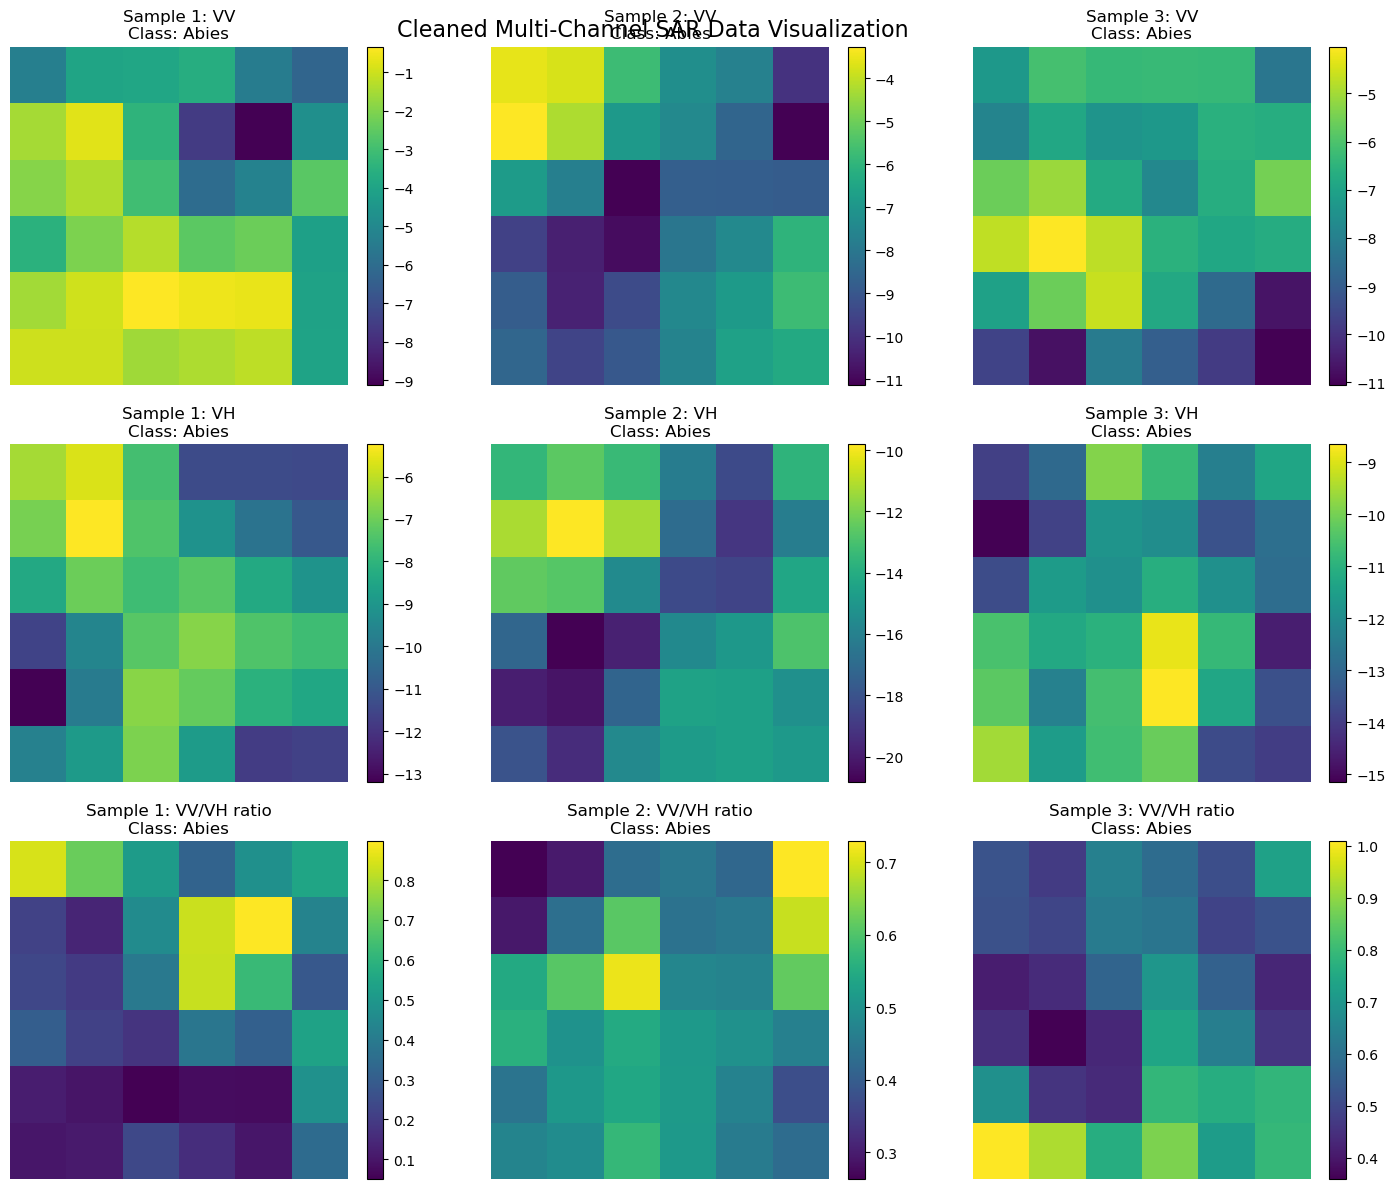

In [ ]:
# Training and validation functions for SimpleUNetClassifier
class TreeSpeciesDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# Create data loaders
batch_size = 64
train_dataset = TreeSpeciesDataset(X_train_tensor, y_train_tensor)
test_dataset = TreeSpeciesDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Training batches: {len(train_loader)}")
print(f"Testing batches: {len(test_loader)}")
print(f"Batch size: {batch_size}")

# Training configuration
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("\nTraining configuration:")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Optimizer: Adam (lr=0.0001, weight_decay=1e-3)")
print(f"  Learning rate scheduler: ReduceLROnPlateau")
print(f"  Input: 3-channel SAR data (VV, VH, VV/VH ratio)")
print(f"  Model: SimpleUNetClassifier (no BatchNorm issues)")


Training batches: 709
Testing batches: 79
Batch size: 64

Training configuration:
  Loss function: CrossEntropyLoss
  Optimizer: Adam (lr=0.0001, weight_decay=1e-3)
  Learning rate scheduler: ReduceLROnPlateau
  Input: 3-channel SAR data (VV, VH, VV/VH ratio)
  Model: SimpleUNetClassifier (no BatchNorm issues)


## Model

In [ ]:
# Simplified UNet-based Classifier without BatchNorm issues
class SimpleConv(nn.Module):
    """Simple Convolution Block without BatchNorm"""
    def __init__(self, in_channels, out_channels):
        super(SimpleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.conv(x)

class SimpleEncoder(nn.Module):
    """Simple Encoder without BatchNorm issues"""
    def __init__(self, n_channels=3):
        super(SimpleEncoder, self).__init__()
        self.n_channels = n_channels
        
        # Simple encoder path without BatchNorm
        self.conv1 = SimpleConv(n_channels, 32)     # 3 -> 32 channels, 6x6
        self.pool1 = nn.MaxPool2d(2)                # 6x6 -> 3x3
        self.conv2 = SimpleConv(32, 64)             # 32 -> 64 channels, 3x3
        self.pool2 = nn.MaxPool2d(2)                # 3x3 -> 1x1 (with padding)
        self.conv3 = SimpleConv(64, 128)            # 64 -> 128 channels, 1x1
        
    def forward(self, x):
        x = self.conv1(x)    # 32 channels, 6x6
        x = self.pool1(x)    # 32 channels, 3x3
        x = self.conv2(x)    # 64 channels, 3x3
        x = self.pool2(x)    # 64 channels, 1x1
        x = self.conv3(x)    # 128 channels, 1x1
        return x

class SimpleUNetClassifier(nn.Module):
    """
    Simple UNet-based Classifier without BatchNorm issues
    
    Features:
    - Uses all 3 SAR channels (VV, VH, VV/VH ratio)
    - No BatchNorm to avoid 1x1 issues
    - Simple and reliable architecture
    - Enhanced regularization with dropout
    """
    def __init__(self, n_channels=3, n_classes=15):
        super(SimpleUNetClassifier, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        
        # Simple encoder for feature extraction
        self.encoder = SimpleEncoder(n_channels)
        
        # Simple classifier with regularization
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # Global average pooling
            nn.Flatten(),             # Flatten to 1D
            nn.Dropout(0.5),          # Dropout for regularization
            nn.Linear(128, 64),       # First FC layer
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),          # Another dropout
            nn.Linear(64, n_classes)  # Final classification layer
        )
        
    def forward(self, x):
        # Extract features using simple encoder
        features = self.encoder(x)  # (batch, 128, 1, 1) for 6x6 input
        
        # Classify using simple classifier
        logits = self.classifier(features)  # (batch, n_classes)
        
        return logits

# Initialize simplified model with 3-channel input
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = SimpleUNetClassifier(n_channels=3, n_classes=len(classes))
model.to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model parameters: {count_parameters(model):,}")
print(f"Input channels: {model.n_channels} (VV, VH, VV/VH ratio)")
print(f"Output classes: {model.n_classes}")

# Test model with 3-channel input
with torch.no_grad():
    test_input = torch.randn(1, 3, 6, 6).to(device)
    test_output = model(test_input)
    print(f"Test input shape: {test_input.shape}")
    print(f"Test output shape: {test_output.shape}")
    print(f"Expected output shape: (1, {len(classes)}) for image-level classification")
    
    # Check if output shape matches expected
    expected_shape = (1, len(classes))
    if test_output.shape != expected_shape:
        print(f"⚠ Warning: Expected {expected_shape}, got {test_output.shape}")


Using device: cpu
Model parameters: 296,239
Input channels: 3 (VV, VH, VV/VH ratio)
Output classes: 15
Test input shape: torch.Size([1, 3, 6, 6])
Test output shape: torch.Size([1, 15])
Expected output shape: (1, 15) for image-level classification


In [21]:
# Training and validation functions
def calculate_metrics(y_true, y_pred):
    """Calculate accuracy metrics for image-level classification"""
    y_true_flat = y_true.cpu().numpy().flatten()
    y_pred_flat = y_pred.cpu().numpy().flatten()
    
    # Calculate image-level accuracy
    image_accuracy = (y_true_flat == y_pred_flat).mean()
    
    # Calculate per-class accuracy
    class_accuracies = []
    for class_idx in range(len(classes)):
        class_mask = y_true_flat == class_idx
        if class_mask.sum() > 0:  # Only calculate if class exists in batch
            class_acc = (y_pred_flat[class_mask] == class_idx).mean()
            class_accuracies.append(class_acc)
        else:
            class_accuracies.append(0.0)
    
    mean_class_accuracy = np.mean(class_accuracies)
    
    return image_accuracy, mean_class_accuracy

def train_epoch(model, train_loader, criterion, optimizer, device, epoch):
    """Training for one epoch"""
    model.train()
    running_loss = 0.0
    
    # Add tqdm progress bar
    pbar = tqdm(train_loader, desc=f'Epoch {epoch} - Training', leave=False)
    
    for batch_idx, (images, labels) in enumerate(pbar):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        current_loss = running_loss / (batch_idx + 1)
        
        # Update progress bar display
        pbar.set_postfix({
            'Loss': f'{current_loss:.4f}',
            'Batch': f'{batch_idx+1}/{len(train_loader)}'
        })
    
    return running_loss / len(train_loader)

def evaluate_model(model, test_loader, criterion, device, epoch):
    """Model evaluation"""
    model.eval()
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    
    # Add tqdm progress bar
    pbar = tqdm(test_loader, desc=f'Epoch {epoch} - Validation', leave=False)
    
    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(pbar):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            predictions = torch.argmax(outputs, dim=1)
            all_predictions.append(predictions)
            all_labels.append(labels)
            
            current_loss = running_loss / (batch_idx + 1)
            pbar.set_postfix({
                'Val Loss': f'{current_loss:.4f}',
                'Batch': f'{batch_idx+1}/{len(test_loader)}'
            })
    
    all_predictions = torch.cat(all_predictions, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    
    avg_loss = running_loss / len(test_loader)
    image_accuracy, mean_class_accuracy = calculate_metrics(all_labels, all_predictions)
    
    return avg_loss, image_accuracy, mean_class_accuracy


In [22]:
# Training loop
print("=== Starting SimpleUNetClassifier Training ===")
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Using 3-channel SAR data (VV, VH, VV/VH ratio)")
print(f"Model parameters: {count_parameters(model):,}")

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_image_accuracy': [],
    'val_class_accuracy': []
}

num_epochs = 10
start_time = time.time()

# Add main progress bar for epoch progress
epoch_pbar = tqdm(range(num_epochs), desc="Training Progress", position=0)

for epoch in epoch_pbar:
    epoch_start = time.time()
    
    # Training
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device, epoch+1)
    
    # Validation
    val_loss, val_image_accuracy, val_class_accuracy = evaluate_model(model, test_loader, criterion, device, epoch+1)
    
    # Update learning rate scheduler
    scheduler.step(val_loss)
    
    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_image_accuracy'].append(val_image_accuracy)
    history['val_class_accuracy'].append(val_class_accuracy)
    
    epoch_time = time.time() - epoch_start
    
    # Update main progress bar with current epoch results
    epoch_pbar.set_postfix({
        'Train Loss': f'{train_loss:.4f}',
        'Val Loss': f'{val_loss:.4f}',
        'Image Acc': f'{val_image_accuracy:.3f}',
        'Time': f'{epoch_time:.1f}s'
    })
    
    # Detailed information output
    print(f"\nEpoch {epoch+1:2d}/{num_epochs} completed:")
    print(f"  Training loss: {train_loss:.4f}")
    print(f"  Validation loss: {val_loss:.4f}")
    print(f"  Image accuracy: {val_image_accuracy:.3f}")
    print(f"  Mean class accuracy: {val_class_accuracy:.3f}")
    print(f"  Time: {epoch_time:.1f}s")

epoch_pbar.close()

total_time = time.time() - start_time
print(f"\n🎉 === Training Completed === 🎉")
print(f"Total training time: {total_time:.1f}s ({total_time/60:.1f} minutes)")
print(f"Average per epoch: {total_time/num_epochs:.1f}s")
print(f"Final image accuracy: {history['val_image_accuracy'][-1]:.4f}")
print(f"Final mean class accuracy: {history['val_class_accuracy'][-1]:.4f}")

# Show training improvement
image_improvement = history['val_image_accuracy'][-1] - history['val_image_accuracy'][0]
class_improvement = history['val_class_accuracy'][-1] - history['val_class_accuracy'][0]
print(f"Image accuracy improvement: {image_improvement:+.4f} ({image_improvement*100:+.2f}%)")
print(f"Class accuracy improvement: {class_improvement:+.4f} ({class_improvement*100:+.2f}%)")


=== Starting SimpleUNetClassifier Training ===
Start time: 2025-10-07 15:29:11
Using 3-channel SAR data (VV, VH, VV/VH ratio)
Model parameters: 1,215,663


Training Progress:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1 - Training:   0%|          | 0/709 [00:00<?, ?it/s]

Epoch 1 - Validation:   0%|          | 0/79 [00:00<?, ?it/s]


Epoch  1/10 completed:
  Training loss: 2.6488
  Validation loss: 2.4144
  Image accuracy: 0.258
  Mean class accuracy: 0.137
  Time: 50.1s


...

Epoch 9 - Validation:   0%|          | 0/79 [00:00<?, ?it/s]


Epoch  9/10 completed:
  Training loss: 2.2270
  Validation loss: 2.2233
  Image accuracy: 0.272
  Mean class accuracy: 0.142
  Time: 53.3s


Epoch 10 - Training:   0%|          | 0/709 [00:00<?, ?it/s]

Epoch 10 - Validation:   0%|          | 0/79 [00:00<?, ?it/s]


Epoch 10/10 completed:
  Training loss: 2.2172
  Validation loss: 2.2258
  Image accuracy: 0.269
  Mean class accuracy: 0.139
  Time: 53.2s

🎉 === Training Completed === 🎉
Total training time: 528.5s (8.8 minutes)
Average per epoch: 52.9s
Final image accuracy: 0.2694
Final mean class accuracy: 0.1386
Image accuracy improvement: +0.0117 (+1.17%)
Class accuracy improvement: +0.0012 (+0.12%)


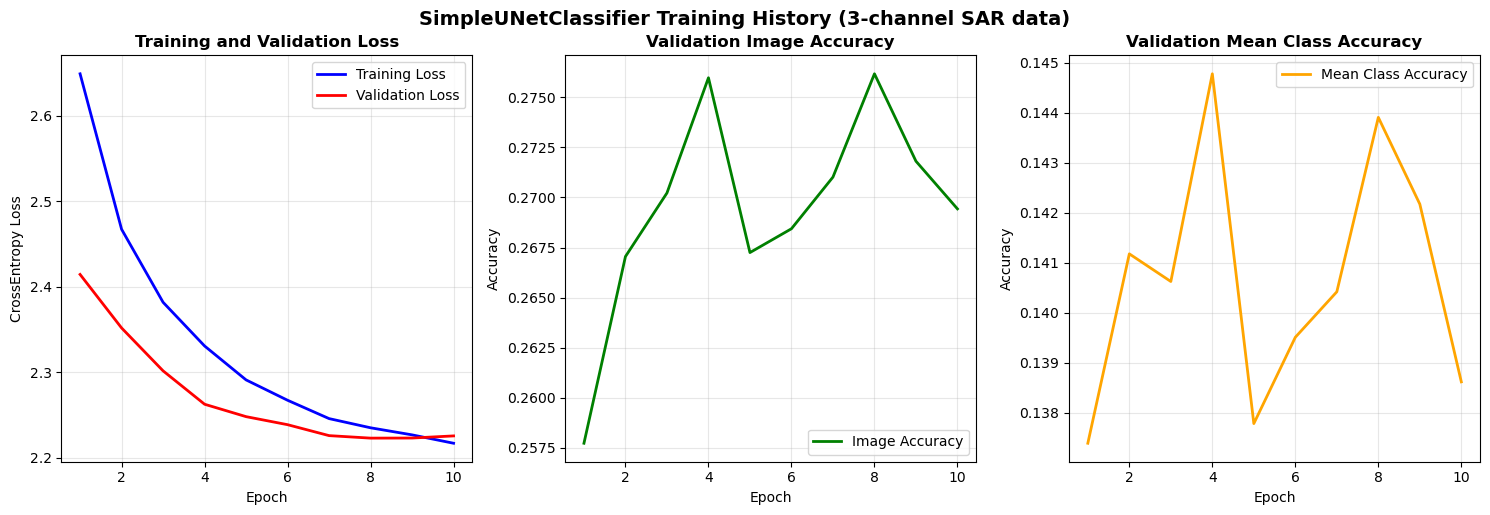


=== Performance Summary ===
Best image accuracy: 0.2762 (epoch 8)
Best class accuracy: 0.1448 (epoch 4)
Image accuracy: 0.2577 → 0.2694
Class accuracy: 0.1374 → 0.1386


In [24]:
# Visualize training history

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curves
axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Training Loss', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
axes[0].set_title('Training and Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('CrossEntropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Image accuracy
axes[1].plot(epochs_range, history['val_image_accuracy'], 'g-', label='Image Accuracy', linewidth=2)
axes[1].set_title('Validation Image Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Mean class accuracy
axes[2].plot(epochs_range, history['val_class_accuracy'], 'orange', label='Mean Class Accuracy', linewidth=2)
axes[2].set_title('Validation Mean Class Accuracy', fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('SimpleUNetClassifier Training History (3-channel SAR data)', fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Performance summary
best_image_epoch = np.argmax(history['val_image_accuracy']) + 1
best_class_epoch = np.argmax(history['val_class_accuracy']) + 1
best_image_accuracy = max(history['val_image_accuracy'])
best_class_accuracy = max(history['val_class_accuracy'])

print("\n=== Performance Summary ===")
print(f"Best image accuracy: {best_image_accuracy:.4f} (epoch {best_image_epoch})")
print(f"Best class accuracy: {best_class_accuracy:.4f} (epoch {best_class_epoch})")
print(f"Image accuracy: {history['val_image_accuracy'][0]:.4f} → {history['val_image_accuracy'][-1]:.4f}")
print(f"Class accuracy: {history['val_class_accuracy'][0]:.4f} → {history['val_class_accuracy'][-1]:.4f}")


In [34]:
# Prediction results for image-level classification
import random

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for test_images, test_labels in test_loader:
        test_images, test_labels = test_images.to(device), test_labels.to(device)
        outputs = model(test_images)
        predictions = torch.argmax(outputs, dim=1)
        all_preds.append(predictions.cpu())
        all_labels.append(test_labels.cpu())

    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    n_samples = min(20, all_preds.size(0))
    indices = random.sample(range(all_preds.size(0)), n_samples)

    print("=== Image-Level Classification Results ===")
    print("Format: Sample [Image_ID] -> True_Label | Predicted_Label")
    print("-" * 60)

    for idx, i in enumerate(indices):
        true_label = all_labels[i].item()
        pred_label = all_preds[i].item()
        true_class = classes[true_label]
        pred_class = classes[pred_label]
        is_correct = "✓" if true_label == pred_label else "✗"
        print(f"Sample {idx+1:2d}: {true_class:>12} | {pred_class:>12} {is_correct}")

    # Calculate overall test accuracy
    test_accuracy = (all_preds == all_labels).float().mean().item()
    print(f"\nTest set accuracy: {test_accuracy:.3f}")

print(f"\n=== Model Summary ===")
print(f"  Input: 3-channel SAR data (VV, VH, VV/VH ratio) - 6x6 pixels")
print(f"  Output: Image-level 15-class tree species classification")
print(f"  Model: SimpleUNetClassifier (no BatchNorm issues)")
print(f"  Model parameters: {count_parameters(model):,}")
print(f"  Training time: {total_time:.1f}s")
print(f"  Final image accuracy: {history['val_image_accuracy'][-1]:.4f}")

print(f"\nClass List ({len(classes)} classes):")
for i, class_name in enumerate(classes):
    print(f"  {i:2d}: {class_name}")


=== Image-Level Classification Results ===
Format: Sample [Image_ID] -> True_Label | Predicted_Label
------------------------------------------------------------
Sample  1:        Pinus |      Quercus ✗
Sample  2:      Quercus |        Picea ✗
Sample  3:        Abies |      Cleared ✗
Sample  4:        Larix |      Quercus ✗
Sample  5:        Larix |        Picea ✗
Sample  6:        Fagus |        Picea ✗
Sample  7:        Pinus |      Quercus ✗
Sample  8:      Quercus |      Quercus ✓
Sample  9:      Quercus |        Pinus ✗
Sample 10:        Picea |      Quercus ✗
Sample 11:        Pinus |        Pinus ✓
Sample 12:        Pinus |      Quercus ✗
Sample 13:        Pinus |        Pinus ✓
Sample 14:        Fagus |        Pinus ✗
Sample 15:  Pseudotsuga |      Quercus ✗
Sample 16:      Populus |      Quercus ✗
Sample 17:        Fagus |      Quercus ✗
Sample 18:       Betula |        Pinus ✗
Sample 19:        Larix |        Pinus ✗
Sample 20:  Pseudotsuga |      Quercus ✗

Test set accuracy

## Loading Data

In [8]:
multilabels_dict = json.load(open(LABELS_FILE))

In [9]:
class_counts = Counter()
for mls in multilabels_dict.values():
    for ml, p in mls:
        class_counts[ml] += 1
class_counts.most_common()

[('Quercus', 15524),
 ('Fagus', 14382),
 ('Picea', 14169),
 ('Pinus', 13748),
 ('Cleared', 7080),
 ('Larix', 6388),
 ('Pseudotsuga', 5754),
 ('Betula', 4344),
 ('Alnus', 4207),
 ('Acer', 3819),
 ('Fraxinus', 3378),
 ('Abies', 1616),
 ('Populus', 684),
 ('Prunus', 482),
 ('Tilia', 286)]

In [10]:
classes = sorted(class_counts)
classes

['Abies',
 'Acer',
 'Alnus',
 'Betula',
 'Cleared',
 'Fagus',
 'Fraxinus',
 'Larix',
 'Picea',
 'Pinus',
 'Populus',
 'Prunus',
 'Pseudotsuga',
 'Quercus',
 'Tilia']

In [11]:
len(classes)

15

### Generate Msgpack

In [ ]:
def convert_binary(labels):
    vec = np.zeros(len(classes), dtype=np.uint8)
    for lab, _ in labels:
        idx = classes.index(lab)
        vec[idx] = 1
    return vec

def decode_tif_image(filepath):
    # 读取tif文件为numpy数组
    with rasterio.open(filepath) as src:
        img = src.read()  # shape: (bands, H, W)
    return img

def gen_from_tif_files(folder_path):
    """
    遍历60m文件夹下所有tif文件，生成样本字典（只包含单个label）
    """
    tif_files = sorted(glob(os.path.join(folder_path, "*.tif")))
    for filepath in tif_files:
        key = os.path.basename(filepath)
        sample = {}
        sample['path'] = filepath
        sample['key'] = key
        # 只取单个label
        sample['label'] = key.split('_', 1)[0]
        try:
            # 只取第一个label
            labels = multilabels_dict[key]
            main_label = labels[0][0] if labels else sample['label']
            sample['label'] = main_label
            # labelvec只对主label做one-hot
            vec = np.zeros(len(classes), dtype=np.uint8)
            if main_label in classes:
                idx = classes.index(main_label)
                vec[idx] = 1
            sample['labelvec'] = vec
            sample['data'] = decode_tif_image(filepath)
            yield sample
        except KeyError:
            print('WARNING: no entry for', key, 'in multilabels file')

# 只处理60m文件夹下的tif文件，转换为msgpack格式（只用单个label，不用multilabel）
output_msgpack = os.path.join(BASE_PATH, '60m.msgpack')
if not os.path.exists(output_msgpack) or os.path.getsize(output_msgpack) == 0:
    from datadings.writer import FileWriter
    # 指向正确的60m数据文件夹
    for_write_folder = '/Volumes/siyux1927/thesis/60m'
    with FileWriter(output_msgpack, overwrite=True) as writer:
        tif_files = sorted(glob(os.path.join(for_write_folder, "*.tif")))
        for filepath in tif_files:
            key = os.path.basename(filepath)
            sample = {}
            sample['path'] = filepath
            sample['key'] = key
            # 只取单个label
            sample['label'] = key.split('_', 1)[0]
            # labelvec只对主label做one-hot
            vec = np.zeros(len(classes), dtype=np.uint8)
            if sample['label'] in classes:
                idx = classes.index(sample['label'])
                vec[idx] = 1
            sample['labelvec'] = vec
            sample['data'] = decode_tif_image(filepath)
            writer.write(sample)
    print(f"Processed {len(tif_files)} samples")

with MsgpackReader(os.path.join(BASE_PATH, '60m.msgpack')) as reader:
    for sample in tqdm(reader):
        pass
sample

In [32]:
def create_msgpack_memory_efficient():
    """内存高效的msgpack创建函数"""
    output_msgpack = os.path.join(BASE_PATH, '60m.msgpack')
    
    if os.path.exists(output_msgpack) and os.path.getsize(output_msgpack) > 1000:
        print(f"msgpack文件已存在")
        return
    
    from datadings.writer import FileWriter
    folder_path = '/Volumes/siyux1927/thesis/60m'
    
    # 获取所有tif文件
    tif_files = sorted(glob(os.path.join(folder_path, "*.tif")))
    total_files = len(tif_files)
    print(f"开始处理 {total_files} 个文件...")
    
    start_time = time.time()
    processed_count = 0
    
    with FileWriter(output_msgpack, overwrite=True) as writer:
        for i, filepath in enumerate(tif_files):
            try:
                key = os.path.basename(filepath)
                
                sample = {
                    'path': filepath,
                    'key': key,
                    'label': key.split('_', 1)[0]
                }
                
                # 创建one-hot向量
                vec = np.zeros(len(classes), dtype=np.uint8)
                if sample['label'] in classes:
                    idx = classes.index(sample['label'])
                    vec[idx] = 1
                sample['labelvec'] = vec
                
                # 读取图像数据（一次性读取，不保存到内存太久）
                with rasterio.open(filepath) as src:
                    sample['data'] = src.read().astype(np.float32)
                
                writer.write(sample)
                processed_count += 1
                
                # 每1000个文件显示进度
                if (i + 1) % 1000 == 0:
                    elapsed = time.time() - start_time
                    speed = processed_count / elapsed
                    eta = (total_files - processed_count) / speed / 60
                    print(f"进度: {i+1}/{total_files} ({(i+1)/total_files*100:.1f}%) "
                          f"速度: {speed:.1f} files/s ETA: {eta:.1f}分钟")
                
            except Exception as e:
                print(f'跳过文件 {filepath}: {e}')
                continue
    
    elapsed = time.time() - start_time
    print(f"\n完成！耗时: {elapsed/60:.1f}分钟，处理了 {processed_count} 个文件")

create_msgpack_memory_efficient()

开始处理 50381 个文件...


60m.msgpack   0% 01:33<00:00, 10.87it/s

进度: 1000/50381 (2.0%) 速度: 10.7 files/s ETA: 77.0分钟


60m.msgpack   0% 03:12<00:00, 10.36it/s

进度: 2000/50381 (4.0%) 速度: 10.4 files/s ETA: 77.4分钟


...

进度: 49000/50381 (97.3%) 速度: 9.3 files/s ETA: 2.5分钟


60m.msgpack   0% 1:28:45<00:00, 13.67it/s

进度: 50000/50381 (99.2%) 速度: 9.4 files/s ETA: 0.7分钟


60m.msgpack   0% 1:29:13<00:00,  9.41it/s

50381 samples written

完成！耗时: 89.2分钟，处理了 50381 个文件


### Directly load from Msgpack

In [4]:
with MsgpackReader(os.path.join(BASE_PATH, '60m.msgpack')) as reader:
    for sample in tqdm(reader):
        pass
sample

  0%|          | 0/50381 [00:00<?, ?it/s]

{'path': '/Volumes/siyux1927/thesis/60m/Tilia_spec._9_99911_WEFL_NLF.tif',
 'key': 'Tilia_spec._9_99911_WEFL_NLF.tif',
 'label': 'Tilia',
 'labelvec': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1], dtype=uint8),
 'data': array([[[ -3.536805  ,  -3.8919563 ,  -2.8303852 ,  -2.417076  ,
           -4.0792856 ,  -6.415561  ],
         [ -4.3640943 ,  -4.9834046 ,  -4.3072658 ,  -3.8844779 ,
           -3.2759032 ,  -1.8037418 ],
         [ -7.763571  ,  -6.0747485 ,  -5.665172  ,  -5.4284887 ,
           -2.4874659 ,  -0.891814  ],
         [ -5.2477946 ,  -3.4966593 ,  -5.132027  ,  -6.702929  ,
           -3.341959  ,  -1.6137811 ],
         [ -3.3711302 ,  -2.073303  ,  -3.680616  ,  -5.133356  ,
           -3.8594565 ,  -3.3540123 ],
         [ -5.2796044 ,  -2.9493341 ,  -2.2050004 ,  -1.9609435 ,
           -2.3596663 ,  -4.0155935 ]],
 
        [[ -9.267127  ,  -9.347546  , -11.599621  , -13.753594  ,
          -15.274427  , -13.023651  ],
         [ -8.555087  , -10.9037695 

In [5]:
def get_item_by_key(self, key):
    self.seek_key(key)
    return next(self)

with MsgpackReader(os.path.join(BASE_PATH, '60m.msgpack')) as reader:
    s = get_item_by_key(reader, TRAIN_FILENAMES[0])
s

{'path': '/Volumes/siyux1927/thesis/60m/Abies_alba_0_2545_WEFL_NLF.tif',
 'key': 'Abies_alba_0_2545_WEFL_NLF.tif',
 'label': 'Abies',
 'labelvec': array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=uint8),
 'data': array([[[ -5.335223  ,  -3.9937298 ,  -3.9333224 ,  -3.6292474 ,
           -5.431843  ,  -6.261381  ],
         [ -1.5071042 ,  -0.7229538 ,  -3.4152293 ,  -7.581895  ,
           -9.110601  ,  -4.7266865 ],
         [ -1.9296857 ,  -1.3718028 ,  -3.023851  ,  -6.023857  ,
           -5.210958  ,  -2.5888844 ],
         [ -3.521139  ,  -2.057495  ,  -1.3079207 ,  -2.5629194 ,
           -2.3128288 ,  -4.1360297 ],
         [ -1.540963  ,  -0.9707865 ,  -0.33564067,  -0.5562592 ,
           -0.6217948 ,  -4.0591245 ],
         [ -0.9909168 ,  -0.99095786,  -1.5892239 ,  -1.4171271 ,
           -1.2030466 ,  -4.0323863 ]],
 
        [[ -6.2998185 ,  -5.6843624 ,  -7.61211   , -11.363376  ,
          -11.382256  , -11.427894  ],
         [ -6.8752775 ,  -5.2331157 ,  -

In [15]:
# First, add the missing get_item_by_key function
def get_item_by_key(reader, key):
    reader.seek_key(key)
    return next(reader)

# Simplified data loading code - only load label and 60m data
v = vars()

# Check if the processed data files already exist
if os.path.exists(os.path.join(BASE_PATH, '60m_test.npy')):
    # If the processed data already exists, load directly
    for _n in 'labels_test, labels_train, data_60m_test, data_60m_train'.split(', '):
        fn = os.path.join(BASE_PATH, _n + '.npy')
        if os.path.exists(fn):
            v[_n] = np.load(fn)
            print(f"Loaded: {_n}")
else:
    # Load data from msgpack file
    for t in ['train', 'test']:
        fns = v[f'{t.upper()}_FILENAMES']
        
        print(f"Processing {t} dataset, total {len(fns)} samples...")
        
        # Only process 60m data (the s1 data you mentioned is the 60m data)
        with MsgpackReader(os.path.join(BASE_PATH, '60m.msgpack')) as reader:
            # Load label data
            print(f"Loading {t} label data...")
            v[f'labels_{t}'] = np.array([classes.index(get_item_by_key(reader, fn)['label']) for fn in tqdm(fns, desc=f'labels_{t}')])
            
            # Load 60m image data
            print(f"Loading {t} 60m image data...")
            v[f'data_60m_{t}'] = np.array([get_item_by_key(reader, fn)['data'] for fn in tqdm(fns, desc=f'60m_{t}')])

    # Save the processed data for fast loading next time
    print("Saving processed data...")
    for _n in 'labels_test, labels_train, data_60m_test, data_60m_train'.split(', '):
        fn = os.path.join(BASE_PATH, _n + '.npy')
        np.save(fn, v[_n])
        print(f"Saved: {_n}")

print("Data loading complete!")
print(f"Training set: {len(labels_train)} samples")
print(f"Test set: {len(labels_test)} samples")
print(f"60m data shape: {data_60m_train.shape}")

Processing train dataset, total 45337 samples...
Loading train label data...


labels_train:   0%|          | 0/45337 [00:00<?, ?it/s]

Loading train 60m image data...


60m_train:   0%|          | 0/45337 [00:00<?, ?it/s]

Processing test dataset, total 5044 samples...
Loading test label data...


labels_test:   0%|          | 0/5044 [00:00<?, ?it/s]

Loading test 60m image data...


60m_test:   0%|          | 0/5044 [00:00<?, ?it/s]

Saving processed data...
Saved: labels_test
Saved: labels_train
Saved: data_60m_test
Saved: data_60m_train
Data loading complete!
Training set: 45337 samples
Test set: 5044 samples
60m data shape: (45337, 3, 6, 6)


In [16]:
labels_train.shape, labels_test.shape

((45337,), (5044,))

In [17]:
data_60m_train.shape, data_60m_test.shape

((45337, 3, 6, 6), (5044, 3, 6, 6))

In [18]:
labels_train[0]

0

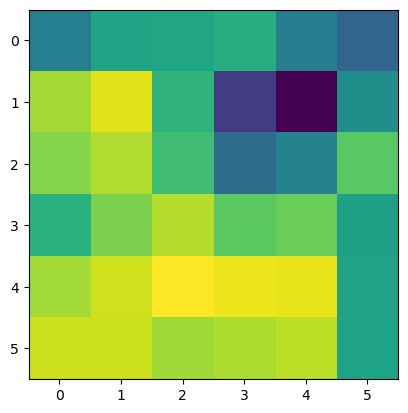

In [19]:
plt.imshow(data_60m_train[0][0])

In [20]:
def show(imgs):
    if not isinstance(imgs, list):
        imgs = [imgs]
    fix, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize=(4*len(imgs), 3))
    for i, img in enumerate(imgs):
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])

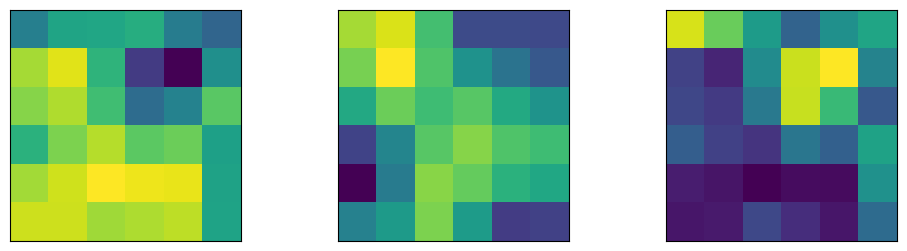

In [21]:
show(list(data_60m_train[0]))

## Training

### LightBGM

In [22]:
X_train = data_60m_train.reshape(len(labels_train), -1)
y_train = labels_train
X_test = data_60m_test.reshape(len(labels_test), -1)
y_test = labels_test

In [23]:
# clf = ltb.LGBMClassifier(
#     boosting_type='gbdt',
#     objective='multiclass',
#     num_class=len(classes),
#     learning_rate=LEARNING_RATE,
#     n_estimators=NUM_ESTIMATORS,
#     #verbose=1,
# )

clf = ltb.LGBMClassifier(n_jobs=min(32, joblib.cpu_count()))  # seems more than 32 actually slows things down
clf.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005804 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 27540
[LightGBM] [Info] Number of data points in the train set: 45337, number of used features: 108
[LightGBM] [Info] Start training from score -3.929534
[LightGBM] [Info] Start training from score -2.882353
[LightGBM] [Info] Start training from score -2.974282
[LightGBM] [Info] Start training from score -2.881959
[LightGBM] [Info] Start training from score -2.505520
[LightGBM] [Info] Start training from score -2.052823
[LightGBM] [Info] Start training from score -2.947443
[LightGBM] [Info] Start training from score -2.787365
[LightGBM] [Info] Start training from score -2.163160
[LightGBM] [Info] Start training from score -1.904137
[LightGBM] [Info] Start training from score -4.773844
[LightGBM] [Info] Start training from score -5.105108
[LightGBM] [Info] Start training from score -2.933253
[LightG

LGBMClassifier(n_jobs=10)

/Users/siyux1927/.micromamba/envs/new/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Model accuracy score: 0.2635
              precision    recall  f1-score   support

       Abies       0.00      0.00      0.00        93
        Acer       0.05      0.01      0.01       282
       Alnus       0.08      0.01      0.01       247
      Betula       0.00      0.00      0.00       281
     Cleared       0.45      0.48      0.47       422
       Fagus       0.20      0.15      0.17       639
    Fraxinus       0.11      0.01      0.02       255
       Larix       0.09      0.02      0.03       316
       Picea       0.21      0.31      0.25       571
       Pinus       0.35      0.65      0.45       759
     Populus       0.00      0.00      0.00        81
      Prunus       0.00      0.00      0.00        29
 Pseudotsuga       0.20      0.05      0.08       278
     Quercus       0.21      0.43      0.28       769
       Tilia       0.00      0.00      0.00        22

    accuracy                           0.26      5044
   macro avg       0.13      0.14      0.1

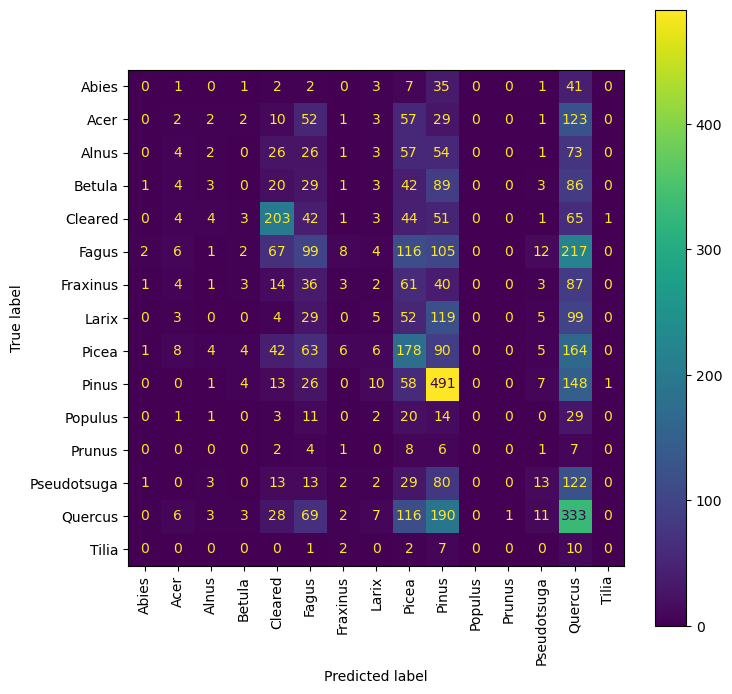

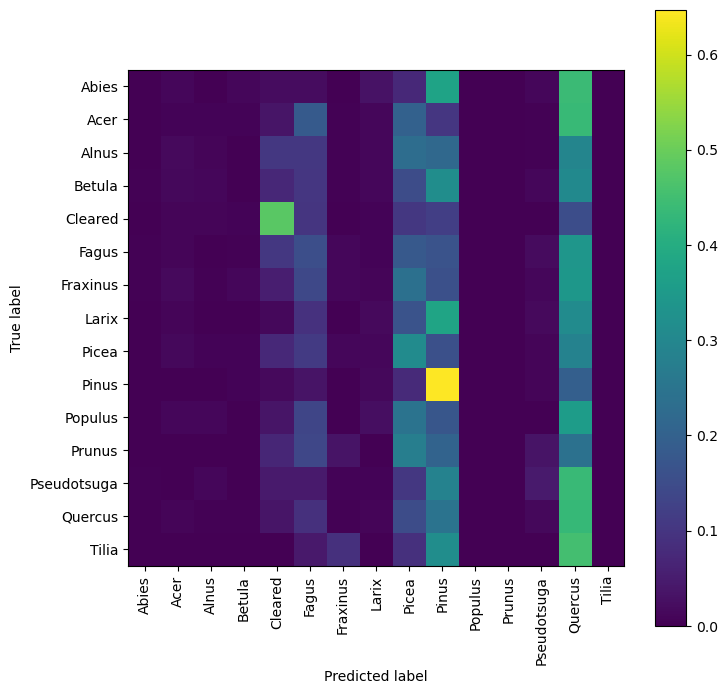

In [24]:
y_pred=clf.predict(X_test)

accuracy=accuracy_score(y_pred, y_test)
print('LightGBM Model accuracy score: {0:0.4f}'.format(accuracy_score(y_test, y_pred)))
print(classification_report(y_test, y_pred, 
                          target_names=classes,
                          labels=list(range(len(classes))),
                          zero_division=0))
# cm = confusion_matrix(y_test, y_pred)
# print(cm)
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=classes, xticks_rotation='vertical', ax=ax)
plt.show()
fig, ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=classes, xticks_rotation='vertical', normalize='true', include_values=False, ax=ax)
plt.show()